In [480]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [481]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [482]:
len(words)

32033

In [483]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [484]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [485]:
# MLP revisited
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5) #* 0.2
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.ones((1, n_hidden))
bnstd_running = torch.zeros((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]  # removed b1
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [486]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    # BatchNorm Layer
    # -------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():  # running mean (method 2)
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

#   break


      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


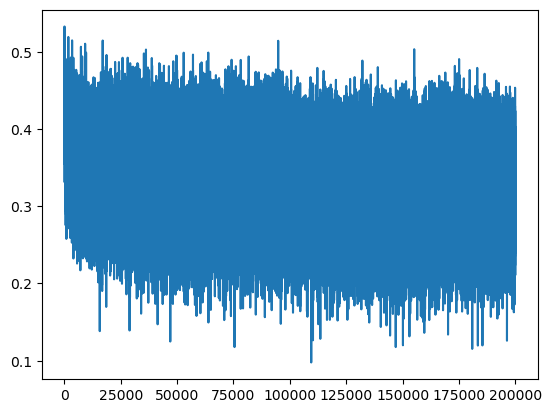

In [487]:
plt.plot(lossi)

In [488]:
# Calibrate the batch norm at the end of training (method 1)

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [489]:
epsilon = 1e-8  # (compare with method 2)
pct_diff_mean = ((bnmean - bnmean_running) / (bnmean_running + epsilon)) * 100
pct_diff_std = ((bnstd - bnstd_running) / (bnstd_running + epsilon)) * 100
pct_diff_mean, pct_diff_mean


(tensor([[-5.2143e-01, -9.7828e-01,  2.8728e-01, -1.3542e-01, -1.3717e+00,
           1.1972e+00,  5.2126e-01, -2.0185e-01,  5.7368e-01,  1.6103e+00,
          -9.6957e-01,  4.5125e-02,  3.4315e+00, -1.7305e+00, -3.6703e-02,
           2.0343e+00,  5.3150e-01,  1.0711e-02, -8.6698e+00,  1.2768e+00,
           1.1245e+00, -2.0385e+01,  4.8720e+00, -1.0204e+00, -3.6926e-01,
          -1.1533e-01, -1.5443e-02, -2.4520e-01,  1.5083e+00,  1.5807e-01,
          -1.5330e+01,  3.8077e-01,  7.1634e+00, -2.0552e-01,  8.6825e-01,
           4.8225e-01,  5.3373e-02,  1.3454e+01,  3.8710e+03, -5.5470e-01,
          -3.8702e+00, -2.4744e+00,  7.5801e-01,  2.7912e+00,  6.5285e-02,
          -5.3957e-01, -2.0672e-01, -2.8731e+00,  8.4200e-01,  1.0759e+00,
          -5.9989e-02, -9.1665e-01,  4.8397e-01,  1.0334e+00,  3.7174e-01,
           8.1840e-02,  2.4587e+00,  9.7665e-01, -8.8341e-01, -5.4290e-01,
          -1.6657e+00,  1.2980e+00,  1.8887e+00,  5.5072e-01,  4.5404e-02,
           1.0465e+00, -6

In [492]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 #+ b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    # hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias  # with mean and std over entire set
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias  # with means and stds from training
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056838035583496


In [491]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        hpreact = emb.view(1, -1) @ W1 #+ b1 # hidden layer pre-activation
        # hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact) # hidden layer
        logits = h @ W2 + b2 # output layer
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carlah.
amorie.
khi.
mri.
reity.
salaysie.
mahnen.
delynn.
jareei.
ner.
kiah.
maiivia.
leigh.
ham.
joce.
quint.
salin.
alianni.
wate.
madiaryn.


# Loss Log
### Original
train 2.1267659664154053

val 2.1697638034820557

### Initialize W2 * 0.01 and b2 = 0
Aims to increase initial entropy (make softmax distribution equal)

train 2.0695888996124268

val 2.131074905395508

### Initilize W2 * 0.2 and b2 * 0.01
Fixing the saturated tanh: because extremne inputs to tanh results in no gradient back. 

train 2.0355966091156006

val 2.1026782989501953

### Initialize first layer with Kaiming initialization
To retain the same standard deviation of 1.0 in activations across layers.

train 2.0376641750335693

val 2.106989622116089

### Batch Normalization
Note that here, batchnorm is not doing much (and in fact Kaiming init already does its job). 
However, it will start to matter more for deeper nets, with for instance residual connections.

train 2.0668270587921143

val 2.1049270629882812

And with running mean/buffer:
train 2.06659197807312
val 2.1050572395324707

And after removing bias:
train 2.0674145221710205
val 2.1056838035583496
